#### Load a dataset

In [1]:
import pandas as pd
import numpy as np
import visualize_scores as visualize
import metrics

scores = pd.read_csv("scores_all.csv")

In [2]:
scores.head(10)

,Prompt,Assignment,EssayType,Writer,Grader,Issues,Evidence,Context,Position,Conclusions,Total,HasZero,Issues_zero,Evidence_zero,Context_zero,Position_zero,Conclusions_zero
0,p0,A1,generate,chatgpt,claude,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
1,p0,A1,generate,chatgpt,gemini,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
2,p0,A1,generate,chatgpt,grok,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
3,p0,A1,generate,claude,chatgpt,4.0,3.0,3.0,3.0,3.0,16.0,False,False,False,False,False,False
4,p0,A1,generate,claude,gemini,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
5,p0,A1,generate,claude,grok,4.0,4.0,3.0,4.0,4.0,19.0,False,False,False,False,False,False
6,p0,A1,generate,gemini,chatgpt,4.0,3.0,3.0,4.0,3.0,17.0,False,False,False,False,False,False
7,p0,A1,generate,gemini,claude,4.0,4.0,3.0,4.0,4.0,19.0,False,False,False,False,False,False
8,p0,A1,generate,gemini,grok,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
9,p0,A1,generate,grok,chatgpt,3.0,3.0,2.0,3.0,3.0,14.0,False,False,False,False,False,False


## Load a human score

In [3]:
pwd

'/Users/ramihuunguyen/Documents/PhD/ai-assessment/src'

#### Check len for each row

In [4]:
prompts = ['p0', 'p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9', 'p10', 'p11', 'p12']

for p in prompts:
    assignment = scores.loc[scores['Prompt'] == p, 'Assignment']
    print(p, len(assignment))

p0 72
p1 72
p2 72
p3 72
p4 72
p5 72
p6 72
p7 72
p8 72
p9 72
p10 70
p11 72
p12 72


In [5]:
p10_generate = scores.loc[(scores['Prompt'] == 'p10') & (scores['EssayType'] == 'generate'), 'Assignment']
print(p10_generate.value_counts().sort_index())
print(len(p10_generate))

Assignment
A1    12
A2    12
A3    10
Name: count, dtype: int64
34


Once ChatGPT receives the P10 generate prompt for A3, it asks for clarification: who is them?. I regenerated this essay few times, but I received the same answer. Therefore, no essay is generated, and thus three scores files for claude, gemini, grok never created.

In [6]:
import json, os

base = "/Users/ramihuunguyen/Documents/PhD/ai-assessment"

score_files = [
    "data/critical_thinking/a3_gen_chatgpt_p10.json"
]

for path in score_files:
    with open(os.path.join(base, path)) as f:
        data = json.load(f)
    
    print(json.dumps(data, indent=2))
    print()

{
  "command": "generate",
  "model": "gpt-5.2-2025-12-11",
  "essay_name": "Assignment_3",
  "folder": "critical_thinking",
  "prompt": "Perform a real estate investment market analysis in the Boston Metropolitan Area for 2024. Summarize the key findings, insights from the analysis, highlight the best real estate investment opportunities, and any significant patterns observed.",
  "prompt_step2": "Let's think step by step. Generate a five-page essay (1000 words or less) to set them straight and include at least 5 citations from peer-reviewed articles.",
  "step1_result": "## Boston Metropolitan Area (Greater Boston) \u2014 Real Estate Investment Market Analysis (2024)\n\n### Executive snapshot (2024)\n- **Market regime:** High-rate, low-transaction environment with **stable-to-rising rents** and **modestly softening prices** in many submarkets\u2014creating **selective buying opportunities**, especially for operators who can add value or navigate regulations.\n- **Demand anchors:** Wo

#### Average Total Score By Essay Type (All Assignments + Prompt Techniques)

In [7]:
techniques = [
    'Baseline',
    'Role-based',
    'Role-based + Formal',
    'CoT',
    'Generate',
    'CoT + Generate',
    'Role-based + Gen',
    'Iter: A + Role-based + Generate',
    'Iter: A + Role-based',
    'Iter: A + Gen',
    'Iter: A + CoT',
    'Iter: A + Write',
    'Iter: A&S + Write'
]

In [8]:
avg_df = metrics.compute_avg_total_by_essaytype(scores, prompts)
avg_df

,Prompt,EssayType,AvgTotal
0,p0,generate,18.25
1,p0,tune,19.47
2,p1,generate,17.50
3,p1,tune,19.44
4,p2,generate,17.69
5,p2,tune,19.36
6,p3,generate,18.39
7,p3,tune,19.47
8,p4,generate,18.31
9,p4,tune,19.47


!pip install jinja2

In [17]:
!pip install jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (2.7 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp314-cp314-macosx_11_0_arm64.whl (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [jinja2]


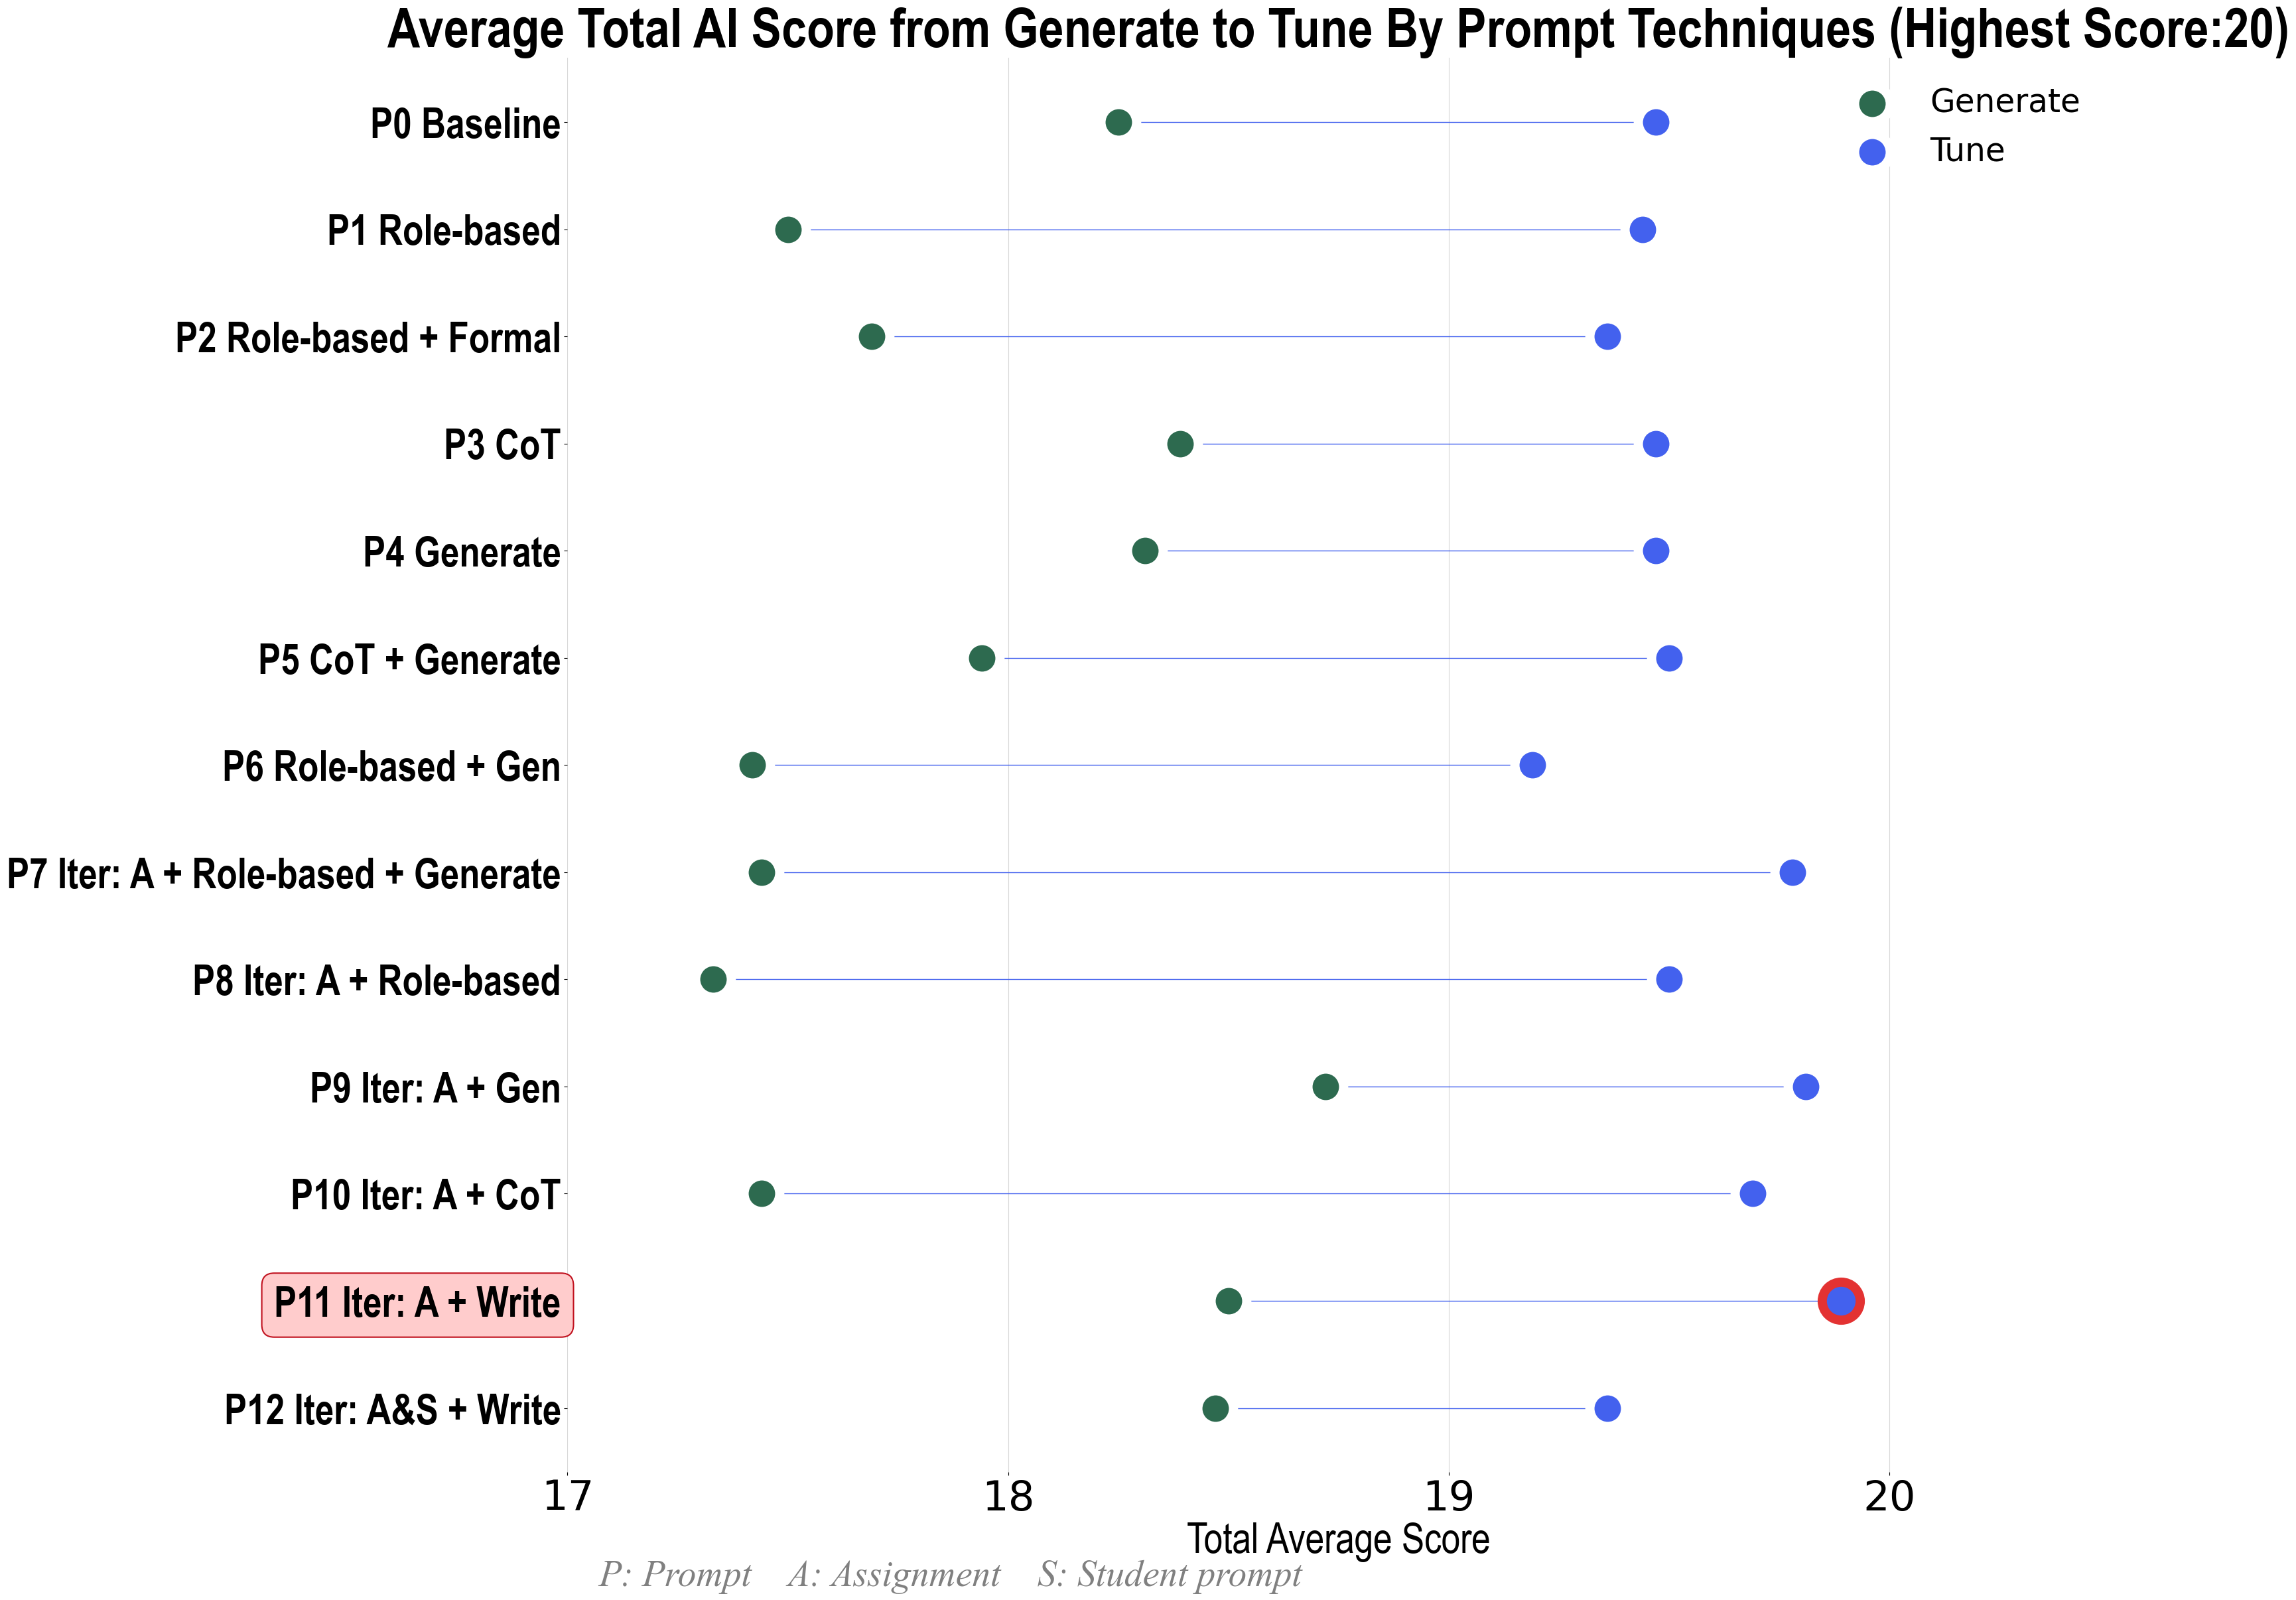

In [8]:
visualize.plot_generate_vs_tune_dumbbell(avg_df, prompts, techniques)

In [13]:
pivot = avg_df.pivot(index='EssayType', columns='Prompt', values='AvgTotal')
pivot = pivot.reindex(columns=sorted(pivot.columns, key=lambda x: int(x[1:])))
pivot.index = ['Generate', 'Tune']
pivot.index.name = 'Score type'
pivot.columns = [f'P{i}' for i in range(13)]

def style_rows(row):
    if row.name == 'Generate':
        base = 'background-color: #D3D1C7; color: #444441'
    else:
        base = 'background-color: #888780; color: #f1f0ec'
    styles = [base] * len(row)
    if row.name == 'Tune':
        p11_idx = list(row.index).index('P11')
        styles[p11_idx] = 'background-color: #085041; color: #E1F5EE; font-weight: 500'
    return styles

prompt_labels = (
    "P: Prompt  |  "
    "P0 Baseline: Write Essay  |  "
    "P1 Role-based: You are an undergrad student  |  "
    "P2 Role-based + Formal  |  "
    "P3 Chain of Thought: Think step-by-step  |  "
    "P4 Generate: Generate Essay  |  "
    "P5 CoT + Generate  |  "
    "P6 Role-based + Gen  |  "
    "P7 Iter: A + Role-based + Generate  |  "
    "P8 Iter: A + Role-based  |  "
    "P9 Iter: A + Gen  |  "
    "P10 Iter: A + CoT  |  "
    "P11 Iter: A + Write  |  "
    "P12 Iter: A&S + Write"
)

caption_text = (
    prompt_labels + "<br>"
    "Light grey → dark grey indicates improvement from Generate to Tune  |  "
    "★ Highest tune score (P11 Iter: A + Write)"
)

styled = pivot.style \
    .apply(style_rows, axis=1) \
    .format("{:.1f}") \
    .format("{:.1f} ★", subset=pd.IndexSlice['Tune', ['P11']]) \
    .set_caption(caption_text) \
    .set_properties(**{'text-align': 'center', 'font-size': '12px', 'border': '0.5px solid #B4B2A9', 'padding': '8px 10px'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#f1f0ec'), ('color', '#5F5E5A'),
            ('font-size', '11px'), ('text-align', 'center'),
            ('border', '0.5px solid #B4B2A9'), ('padding', '8px 10px')
        ]},
        {'selector': 'th.row_heading', 'props': [
            ('text-align', 'left'), ('padding-left', '12px')
        ]},
        {'selector': 'caption', 'props': [
            ('font-size', '11px'), ('color', '#5F5E5A'),
            ('text-align', 'left'), ('padding', '8px 0 4px 0'),
            ('caption-side', 'bottom'), ('line-height', '1.8')
        ]}
    ])

styled

,P0,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12
Score type,,,,,,,,,,,,,
Generate,18.2,17.5,17.7,18.4,18.3,17.9,17.4,17.4,17.3,18.7,17.4,18.5,18.5
Tune,19.5,19.4,19.4,19.5,19.5,19.5,19.2,19.8,19.5,19.8,19.7,19.9 ★,19.4


In [18]:
!pip install imgkit


In [9]:
p11_tuned = scores[(scores['Prompt'] == 'p11') & (scores['EssayType'] == 'tune')]
print(p11_tuned.groupby('Assignment')['Total'].count())


Assignment
A1    12
A2    12
A3    12
Name: Total, dtype: int64


In [10]:
p11_avg_tuned = scores[(scores['Prompt'] == 'p11') & (scores['EssayType'] == 'tune')].groupby('Assignment')['Total'].mean().round(2)
p11_avg_tuned

Assignment
A1    19.92
A2    19.75
A3    20.00
Name: Total, dtype: float64

In [24]:
!brew install wkhtmltopdf


==> Auto-updating Homebrew...
Adjust how often this is run with `$HOMEBREW_AUTO_UPDATE_SECS` or disable with
`$HOMEBREW_NO_AUTO_UPDATE=1`. Hide these hints with `$HOMEBREW_NO_ENV_HINTS=1` (see `man brew`).
==> Downloading https://ghcr.io/v2/homebrew/core/portable-ruby/blobs/sha256:f41c72b891c40623f9d5cd2135f58a1b8a5c014ae04149888289409316276c72
######################################################################### 100.0%
==> Pouring portable-ruby-4.0.2_1.arm64_big_sur.bottle.tar.gz
==> Auto-updated Homebrew!
Updated 2 taps (homebrew/core and homebrew/cask).
==> New Formulae
aoe: Terminal session manager for AI coding agents
apache-arrow-adbc: Cross-language, Arrow-native database access
apache-serf: High-performance asynchronous HTTP client library
apkeep: Command-line tool for downloading APK files from various sources
asc: Fast, lightweight CLI for App Store Connect
async-profiler: Sampling CPU & HEAP profiler for Java using AsyncGetCallTrace + perf_events
atuin-server: Sync serve

In [34]:
!brew install wkhtmltopdf


⠋ JSON API formula.jws.json                          Downloading  31.9MB/-------
⠋ JSON API cask.jws.json                             Downloading  15.4MB/-------⠋ JSON API formula.jws.json                          Downloading  31.9MB/-------
⠋ JSON API cask.jws.json                             Downloading  15.4MB/-------⠙ JSON API formula.jws.json                          Downloading  31.9MB/-------
⠚ JSON API cask.jws.json                             Downloaded   15.4MB/-------✔︎ JSON API formula.jws.json                          Downloaded   31.9MB/ 31.9MB
✔︎ JSON API cask.jws.json                             Downloaded   15.4MB/ 15.4MB
==> Searching for similarly named formulae and casks...
Error: No formulae or casks found for wkhtmltopdf.


In [37]:
import pandas as pd
import imgkit
from IPython.display import display, HTML

# Pivot
pivot = avg_df.pivot(index='EssayType', columns='Prompt', values='AvgTotal')
pivot = pivot.reindex(columns=sorted(pivot.columns, key=lambda x: int(x[1:])))
pivot.index = ['Generate', 'Tune']
pivot.index.name = None
pivot.columns = [f'P{i}' for i in range(13)]
pivot.columns.name = 'Prompt techniques'

# Style function
def style_rows(row):
    if row.name == 'Generate':
        base = 'background-color: #D3D1C7; color: #444441'
    else:
        base = 'background-color: #888780; color: #f1f0ec'
    styles = [base] * len(row)
    if row.name == 'Tune':
        p11_idx = list(row.index).index('P11')
        styles[p11_idx] = 'background-color: #085041; color: #E1F5EE; font-weight: 500'
    return styles

# Styled table
styled = pivot.style \
    .apply(style_rows, axis=1) \
    .format("{:.1f}") \
    .format("{:.1f} ★", subset=pd.IndexSlice['Tune', ['P11']]) \
    .set_properties(**{'text-align': 'center', 'font-size': '12px', 'border': '0.5px solid #B4B2A9', 'padding': '8px 10px', 'font-family': 'Arial, sans-serif'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#f1f0ec'), ('color', '#5F5E5A'),
            ('font-size', '11px'), ('text-align', 'center'),
            ('border', '0.5px solid #B4B2A9'), ('padding', '8px 10px'),
            ('font-family', 'Arial, sans-serif')
        ]},
        {'selector': 'th.row_heading', 'props': [
            ('text-align', 'left'), ('padding-left', '12px')
        ]},
        {'selector': 'th.blank', 'props': [
            ('background-color', '#f1f0ec'), ('color', '#5F5E5A'),
            ('font-size', '11px'), ('font-weight', '500'),
            ('text-align', 'left'), ('padding-left', '12px'),
            ('border', '0.5px solid #B4B2A9'),
            ('font-family', 'Arial, sans-serif')
        ]}
    ])

# Legend HTML
prompt_legend = """
<div style="font-family: Arial, sans-serif; font-size:11px; color:#5F5E5A; margin-top:10px; border: 0.5px solid #B4B2A9; border-radius:4px; padding:10px 14px; line-height:1.8;">
  <div style="margin-bottom:6px; color:#5F5E5A;">
    <span style="font-weight:700; color:#444441;">P:</span> Prompt &nbsp;|&nbsp;
    <span style="font-weight:700; color:#444441;">A:</span> Assignment Prompt &nbsp;|&nbsp;
    <span style="font-weight:700; color:#444441;">S:</span> Student Prompt &nbsp;|&nbsp;
    <span style="font-weight:700; color:#444441;">Iter:</span> Iterative
  </div>
  <table style="width:100%; border-collapse:collapse; margin-top:4px; font-family: Arial, sans-serif;">
    <tr>
      <td style="padding:2px 6px 2px 0; white-space:nowrap; color:#888780;"><span style="font-weight:700; color:#5F5E5A;">P0</span> Baseline: Write Essay</td>
      <td style="padding:2px 6px 2px 0; white-space:nowrap; color:#888780;"><span style="font-weight:700; color:#5F5E5A;">P1</span> Role-based: Undergrad student</td>
      <td style="padding:2px 6px 2px 0; white-space:nowrap; color:#888780;"><span style="font-weight:700; color:#5F5E5A;">P2</span> Role-based + Formal</td>
      <td style="padding:2px 6px 2px 0; white-space:nowrap; color:#888780;"><span style="font-weight:700; color:#5F5E5A;">P3</span> CoT: Think step-by-step</td>
      <td style="padding:2px 6px 2px 0; white-space:nowrap; color:#888780;"><span style="font-weight:700; color:#5F5E5A;">P4</span> Generate Essay</td>
      <td style="padding:2px 6px 2px 0; white-space:nowrap; color:#888780;"><span style="font-weight:700; color:#5F5E5A;">P5</span> CoT + Generate</td>
      <td style="padding:2px 6px 2px 0; white-space:nowrap; color:#888780;"><span style="font-weight:700; color:#5F5E5A;">P6</span> Role-based + Gen</td>
    </tr>
    <tr>
      <td style="padding:2px 6px 2px 0; white-space:nowrap; color:#888780;"><span style="font-weight:700; color:#5F5E5A;">P7</span> Iter: A + Role + Gen</td>
      <td style="padding:2px 6px 2px 0; white-space:nowrap; color:#888780;"><span style="font-weight:700; color:#5F5E5A;">P8</span> Iter: A + Role-based</td>
      <td style="padding:2px 6px 2px 0; white-space:nowrap; color:#888780;"><span style="font-weight:700; color:#5F5E5A;">P9</span> Iter: A + Gen</td>
      <td style="padding:2px 6px 2px 0; white-space:nowrap; color:#888780;"><span style="font-weight:700; color:#5F5E5A;">P10</span> Iter: A + CoT</td>
      <td style="padding:2px 6px 2px 0; white-space:nowrap; color:#888780;"><span style="font-weight:700; color:#5F5E5A;">P11</span> Iter: A + Write</td>
      <td style="padding:2px 6px 2px 0; white-space:nowrap; color:#888780;"><span style="font-weight:700; color:#5F5E5A;">P12</span> Iter: A&amp;S + Write</td>
      <td></td>
    </tr>
  </table>
  <div style="margin-top:8px; border-top:0.5px solid #D3D1C7; padding-top:6px; color:#888780;">
    Light grey &#8594; dark grey indicates improvement from Generate to Tune &nbsp;|&nbsp; ★ Highest tune score (P11 Iter: A + Write)
  </div>
</div>
"""

# Display in notebook
display(styled)
display(HTML(prompt_legend))

# Save as PNG
full_html = f"""
<html>
<head>
<style>
  body {{ background: transparent; margin: 20px; font-family: Arial, sans-serif; }}
  table {{ border-collapse: collapse; }}
</style>
</head>
<body>
{styled.to_html()}
{prompt_legend}
</body>
</html>
"""

Prompt techniques,P0,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12
Generate,18.2,17.5,17.7,18.4,18.3,17.9,17.4,17.4,17.3,18.7,17.4,18.5,18.5
Tune,19.5,19.4,19.4,19.5,19.5,19.5,19.2,19.8,19.5,19.8,19.7,19.9 ★,19.4


P0 Baseline: Write Essay,P1 Role-based: Undergrad student,P2 Role-based + Formal,P3 CoT: Think step-by-step,P4 Generate Essay,P5 CoT + Generate,P6 Role-based + Gen
P7 Iter: A + Role + Gen,P8 Iter: A + Role-based,P9 Iter: A + Gen,P10 Iter: A + CoT,P11 Iter: A + Write,P12 Iter: A&S + Write,


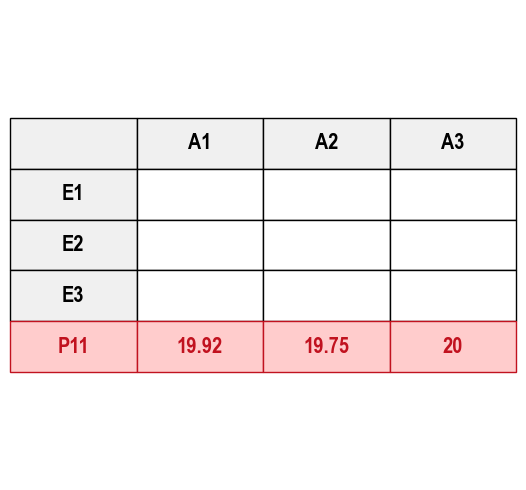

In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 5))
ax.axis('off')

# Table data
row_labels = ['', 'E1', 'E2', 'E3', 'P11']
col_labels = ['', 'A1', 'A2', 'A3']

table_data = [
    ['', 'A1', 'A2', 'A3'],
    ['E1', '', '', ''],
    ['E2', '', '', ''],
    ['E3', '', '', ''],
    ['P11', '19.92', '19.75', '20']
]

# Create table
table = ax.table(
    cellText=table_data,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(16)
table.scale(1.5, 2.5)

# Style all cells
for i in range(5):
    for j in range(4):
        cell = table[i, j]
        cell.set_text_props(fontfamily='Arial Narrow', color='black')
        cell.set_edgecolor('black')
        cell.set_linewidth(1)
        
        # Header row and first column bold
        if i == 0 or j == 0:
            cell.set_text_props(fontweight='bold', fontfamily='Arial Narrow', color='black')
            cell.set_facecolor('#f0f0f0')
        else:
            cell.set_facecolor('white')
        
        # P11 row (row index 4) - orange/red color
        if i == 4:
            cell.set_text_props(fontweight='bold', fontfamily='Arial Narrow', color='#c1121f')
            cell.set_facecolor('#ffcccc')
            cell.set_edgecolor('#c1121f')

plt.tight_layout()
plt.savefig('score_table.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Insights 

1. Tune essays consistently outperfrom Generate across all prompts. 
2. Best generate prompt is prompt 9 (interative + generate) at 18.75.

For higher ed journal: 

- Students do not need to know anything about AI to get an A. That is the problem.


Research Question: To what extent can undergraduate students produce high-scoring critical thinking essays using minimal AI prompting, and how do these scores compare to human expert evaluations using AAC&U VALUE rubrics?

Although prompt 9 (interative+generate) reached at 18.75 is actually strong generate score, but it contracts with my argument: is it complex prompt. 

- Look at Prompt 0 (write) at 18.61: this is the strongest case. It includes the most minimal prompt possible. 
  - Students need zero knowledge of prompting to use it. 

For computer science journal:

Research Question: 

1. Which rubric dimensions produce the greatest divergence among LLM evaluators?
2. How does prompt engineering complexity affect scores of AI-generated essays and AI-tuned essays assigned by four LLM evaluators and human expert raters using AAC&U VALUE rubrics?


#### Writer Performance By Dimension (All Assignments + Prompt Techniques)

In [12]:
writers = ['chatgpt', 'claude', 'gemini', 'grok']
dimensions = ['Issues', 'Evidence', 'Context', 'Position', 'Conclusions']

PROMPT_LABELS = {
    'p0':  'Baseline',
    'p1':  'Role-based',
    'p2':  'Role + Formal',
    'p3':  'Chain of Thought',
    'p4':  'Generate Knowledge',
    'p5':  'CoT + Gen Know',
    'p6':  'Role + Gen Know',
    'p7':  'Role + CoT + Gen Know',
    'p8':  'Iter + Role',
    'p9':  'Iter + Gen Know',
    'p10': 'Iter + CoT + Gen Know',
    'p11': 'Iter + Original',
    'p12': 'Iter + Context'
}


In [13]:
scores.head(5)

,Prompt,Assignment,EssayType,Writer,Grader,Issues,Evidence,Context,Position,Conclusions,Total,HasZero,Issues_zero,Evidence_zero,Context_zero,Position_zero,Conclusions_zero
0,p0,A1,generate,chatgpt,claude,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
1,p0,A1,generate,chatgpt,gemini,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
2,p0,A1,generate,chatgpt,grok,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
3,p0,A1,generate,claude,chatgpt,4.0,3.0,3.0,3.0,3.0,16.0,False,False,False,False,False,False
4,p0,A1,generate,claude,gemini,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False


In [14]:
#Issues_consensus = (4 + 4 + 4) / 3 = 4.0
#abs_bias = how far each grader deviated from consensus
##  chatgpt: |4.0 - 4.0| = 0.0
## gemini:  |3.0 - 4.0| = 1.0 
## grok:    |4.0 - 4.0| = 0.0
# MeanBias = average of ALL abs_bias values across all dimensions and all graders
## 5 dimensions: (0.0 + 1.0 + 0.0 + 0.0 + 0.0 + ...) / 60 = 0.2333

In [15]:
bias_prompt_assignment_df = metrics.compute_bias_by_prompt_assignment(scores, writers, dimensions)
bias_prompt_assignment_df.head()

#group by prompt, essaytype, writer, assignment
#5 dimensions x 12 graders = 60 values (average bias across all writer, all graders, and all dimensions)

,Prompt,Assignment,EssayType,N,MeanBias,StdBias,MaxBias,MinBias
0,p0,A1,generate,60,0.2667,0.2515,0.6667,0.0
1,p0,A1,tune,60,0.1556,0.2334,0.6667,0.0
2,p0,A2,generate,60,0.1556,0.2334,0.6667,0.0
3,p0,A2,tune,60,0.1333,0.2230,0.6667,0.0
4,p0,A3,generate,60,0.4556,0.2452,1.3333,0.0


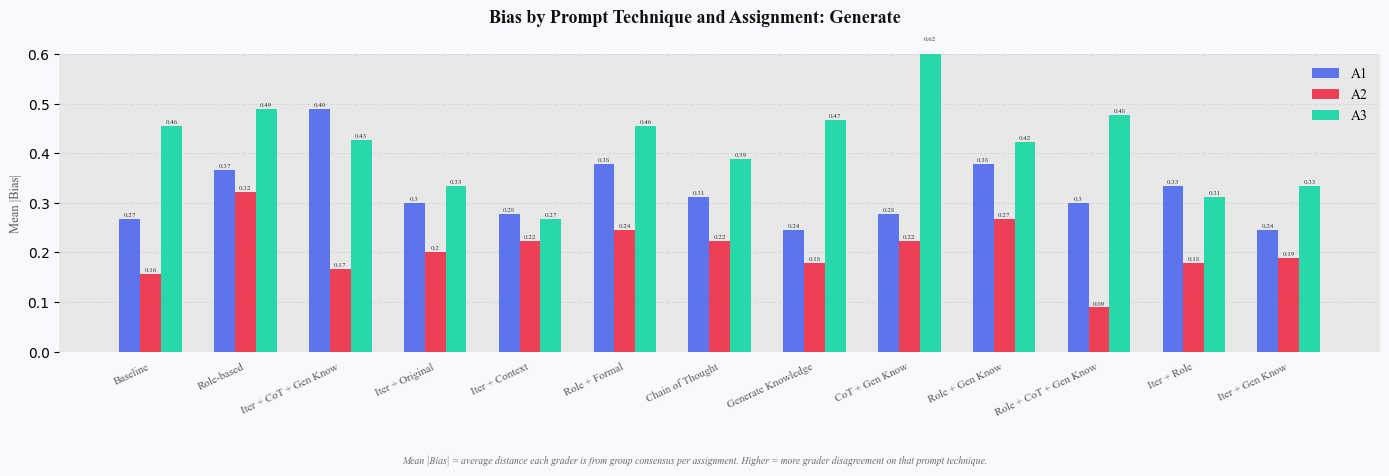

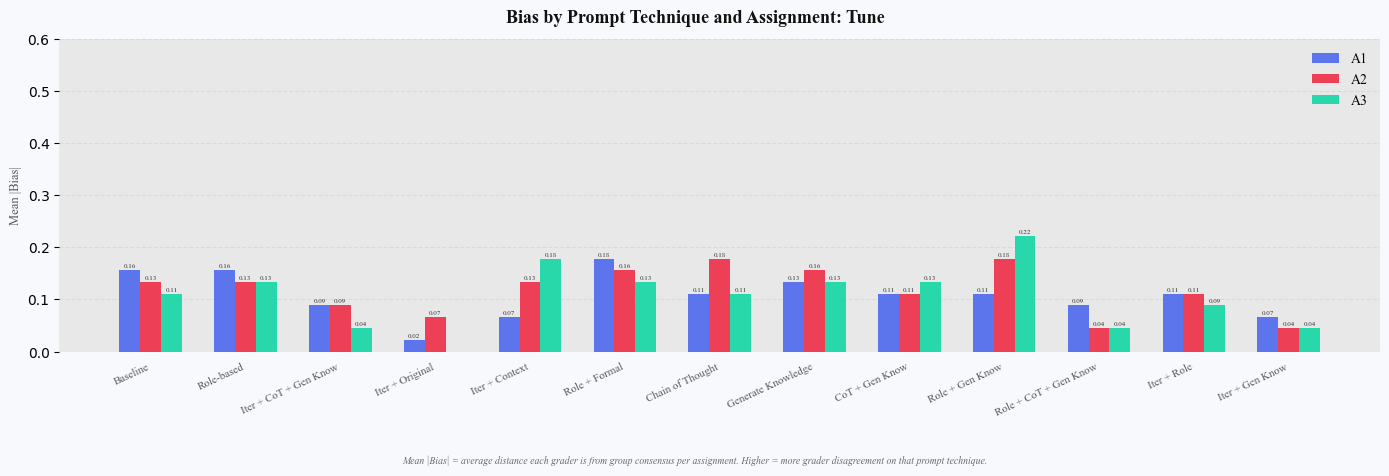

In [16]:
visualize.plot_bias_by_prompt_assignment(bias_prompt_assignment_df, PROMPT_LABELS)

#### 3.How does increasing prompt complexity influence generated and tune essays scores across different LLM evaluators?

### Average Total Scores by All Writers Across 12 Prompts

In [17]:
technique_groups = {
    'Baseline': ['p0'],
    'Single':   ['p1', 'p3', 'p4'],
    'Double':   ['p2', 'p5', 'p6'],
    'Iterative_Prompt':         ['p11', 'p8', 'p9', 'p12'],
    'Iterative_Prompt_Complex': ['p7', 'p10']
}

In [18]:
avg_writer_df = metrics.compute_avg_total_by_writer_prompt(scores, writers, prompts, technique_groups)

In [19]:
avg_writer_df.head()
#group by writer, prompt, essay 
#4 writer x 12 prompts x 2 essay types

,EssayType,Writer,Prompt,AvgTotal
0,generate,chatgpt,p0,19.22
1,generate,chatgpt,p1,18.78
2,generate,chatgpt,p3,19.56
3,generate,chatgpt,p4,19.22
4,generate,chatgpt,p2,19.22


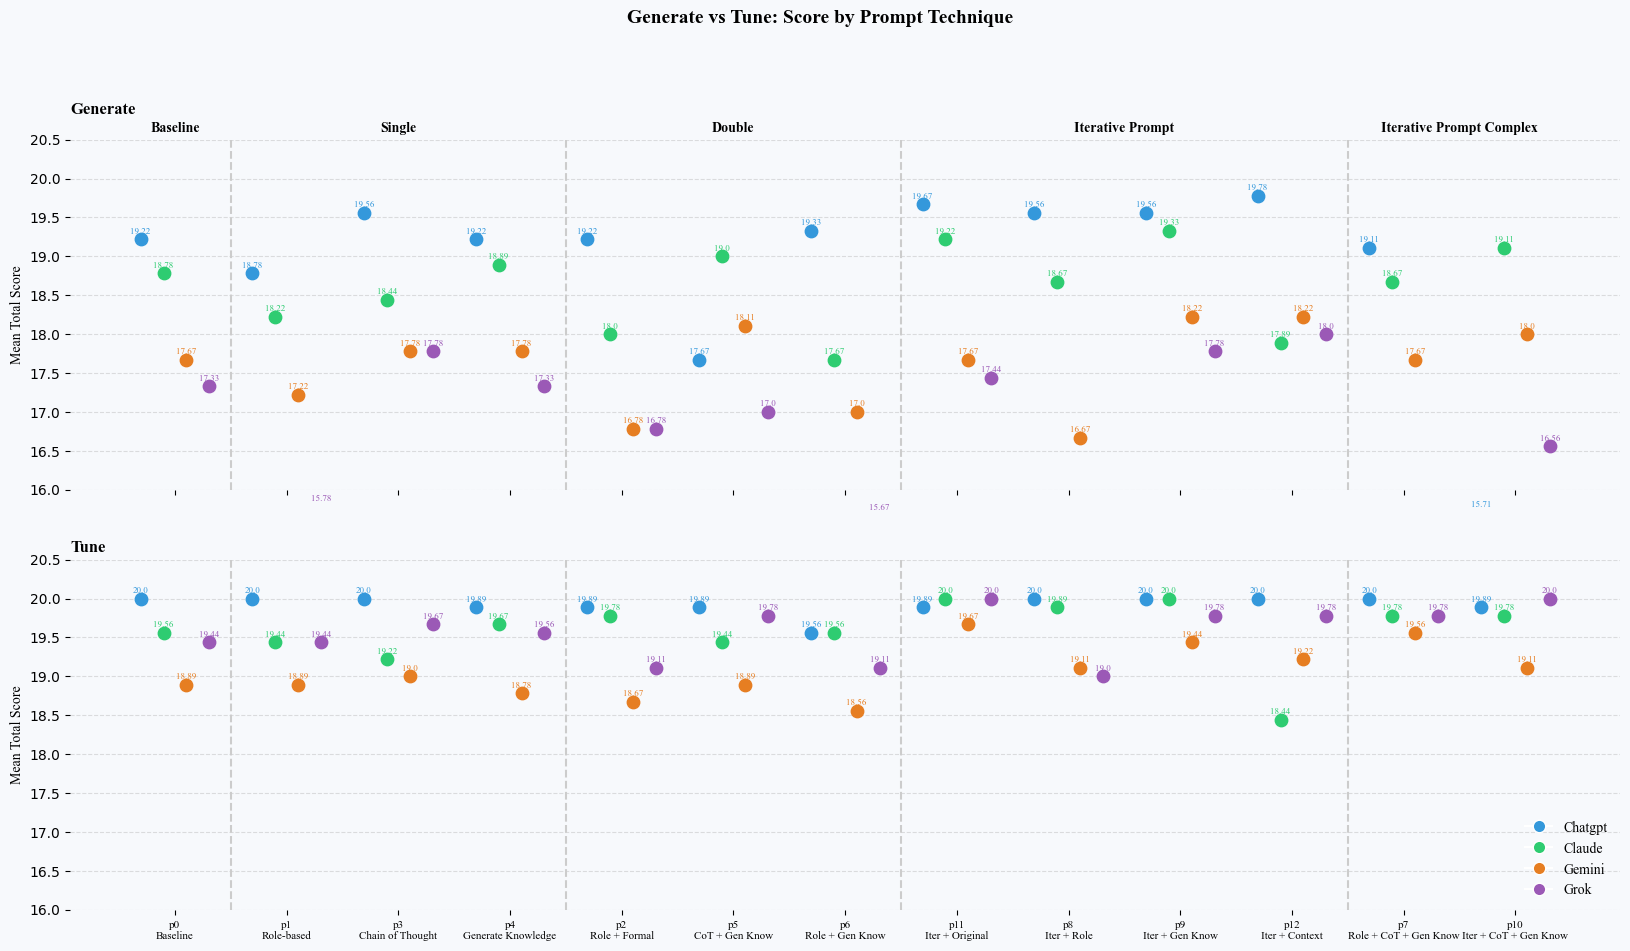

In [20]:
visualize.all_models_performance(avg_writer_df, writers, prompts, technique_groups, PROMPT_LABELS)

**Tune essay scores are stable across models.**
  
  - ChatGPT Tune stays near 20.
  - Claude Tune stays around 19.4–19.7.
  - Gemini Tune stays around 19.1–19.6.
  - Grok Tune stays around 18.9–19.8.

--> Prompt complexity barely moves Tune performance.

**Most stable → Least stable Models:**

1. ChatGPT
2. Claude
3. Gemini
4. Grok

**Tuning Effect Strength**
1. Grok
2. Gemini
3. Claude
4. ChatGPT

### All models Insights

1. Under generated essay conditions, the impact of prompt complexity varies by model.

2. Tuning reduces performance volatility across prompt techniques.

3. Role-based prompting techniques can degrade performance in generated essay conditions.

#### Average Total Scores by Each Writer Across Prompts

#### ChatGPT

In [21]:
trend_df, prompt_order = metrics.compute_trend_by_writer_prompt(scores, writers, prompts, technique_groups)

In [22]:
trend_df
#group by writer, prompt, essay type
#4 writers x 12 prompts x 2 essay type

,EssayType,Writer,Prompt,AvgTotal
0,generate,chatgpt,p0,19.22
1,generate,chatgpt,p1,18.78
2,generate,chatgpt,p3,19.56
3,generate,chatgpt,p4,19.22
4,generate,chatgpt,p2,19.22
...,...,...,...,...
99,tune,grok,p8,19.00
100,tune,grok,p9,19.78
101,tune,grok,p12,19.78
102,tune,grok,p7,19.78


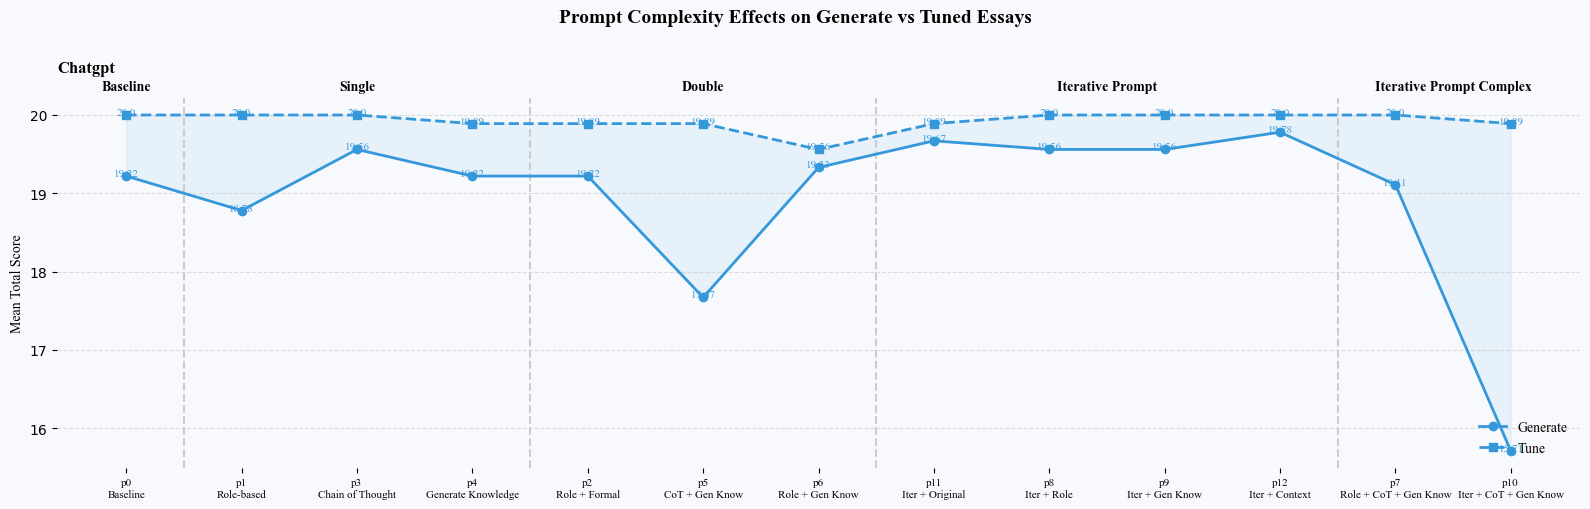

In [23]:
visualize.plot_trend(trend_df, prompt_order, ['chatgpt'], technique_groups, PROMPT_LABELS)

Overall trends:

- Tune consistently scores higher than Generate across almost all prompt techniques.
  - Tune remains near the ceiling (≈20) regardless of prompt complexity.
- Generate scores fluctuate much more across techniques.
- The largest gap between Generate and Tune appears in double-prompt CoT + Generate (p5).
- Single Prompt (P3), and Iterative prompts (p11, p8, p9) has the highest total average of Generate scores.




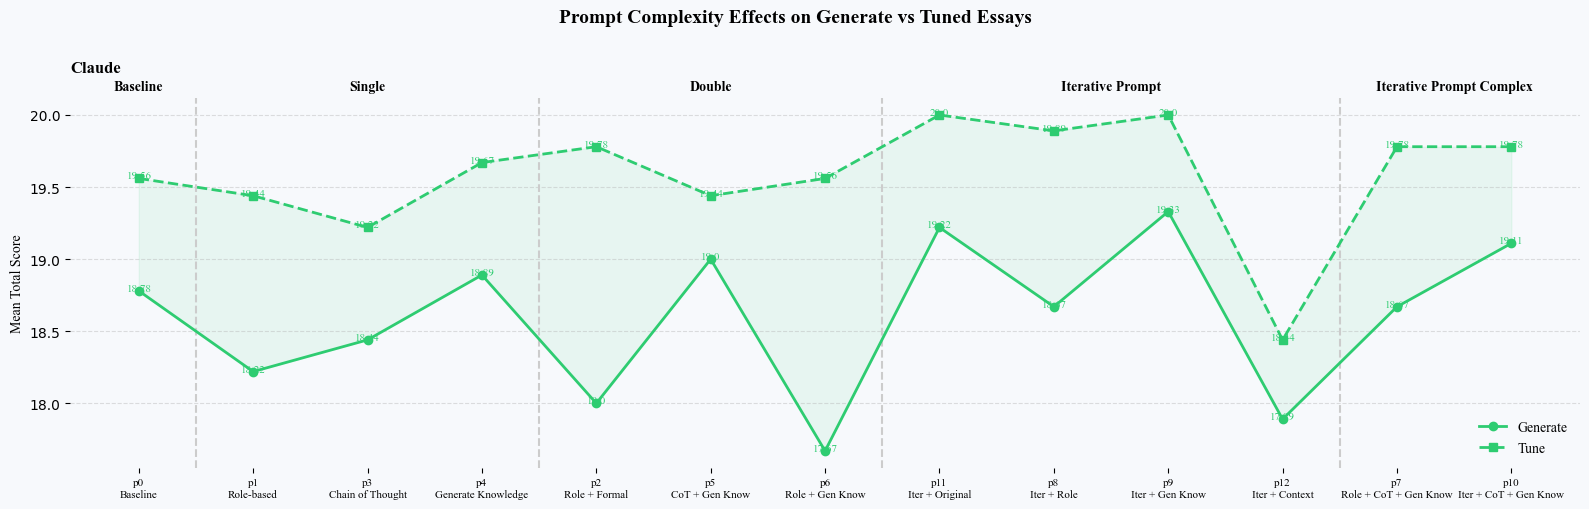

In [24]:
visualize.plot_trend(trend_df, prompt_order, ['claude'], technique_groups, PROMPT_LABELS)

Overall trends: (Claude)

- Tune scores consistently outperforms Generat scores across all prompt techniques.
- Tune scores are relatively stable (≈19.4–19.8).
- The performance gap between Generate and Tune widens under some complex prompt combinations.

  - Baseline: Tuning provides an immediate score performance lift.

  - Single Prompt Additions: Role prompting harms Generate performance for Claude.

  - Double Prompt Additions: Role + Generate has the lowest total average score for generated essays.
    
  - Iterative Prompt: Iteration helps, especially when paired with Generate Knowledge.

  - Iterative Complex: Unlike ChatGPT, Claude does not decline at highest complexity.

-> Claude seems to handle layered structure better when iteration is included.

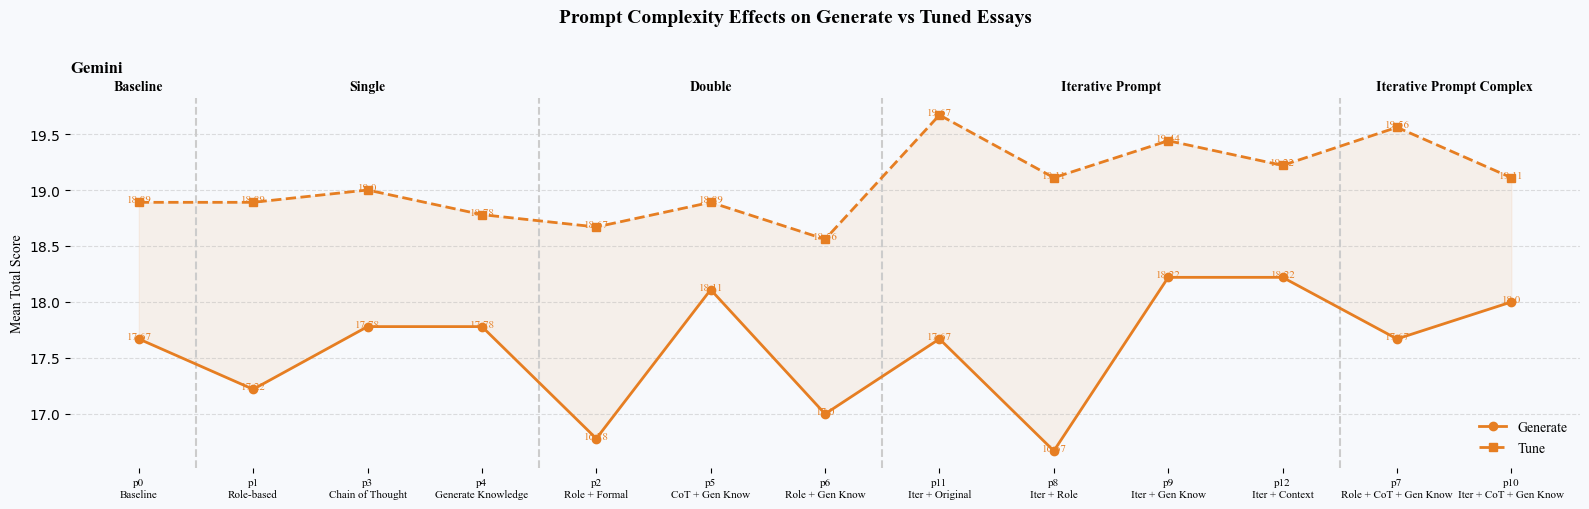

In [25]:
visualize.plot_trend(trend_df, prompt_order, ['gemini'], technique_groups, PROMPT_LABELS)

Overall trends: (Gemini)

- Tune scores consistently outperform Generate scores across all prompt techniques, unless the p10 (interative + Chain Of Thought + Generate Knowledge).
- Tune scores are moderately stable (≈19.1–19.7), with some fluctuation.
- The performance gap between Generate and Tune widens under role-based and iterative-role combinations.

- Baseline:
  - Tuning provides an immediate performance lift (~19.22 vs 18.78).
  
- Single Prompt Additions:
  - Gemini is sensitive to role framing but responds positively to reasoning structure.
  
- Double Prompt Additions:
  - Role-based combinations consistently destabilize Generate's scores.

- Iterative Prompt:
  - Iteration helps only when not combined with role prompting.

- Iterative Complex:
  - Unlike Claude, Gemini does not strongly benefit from highest complexity levels.

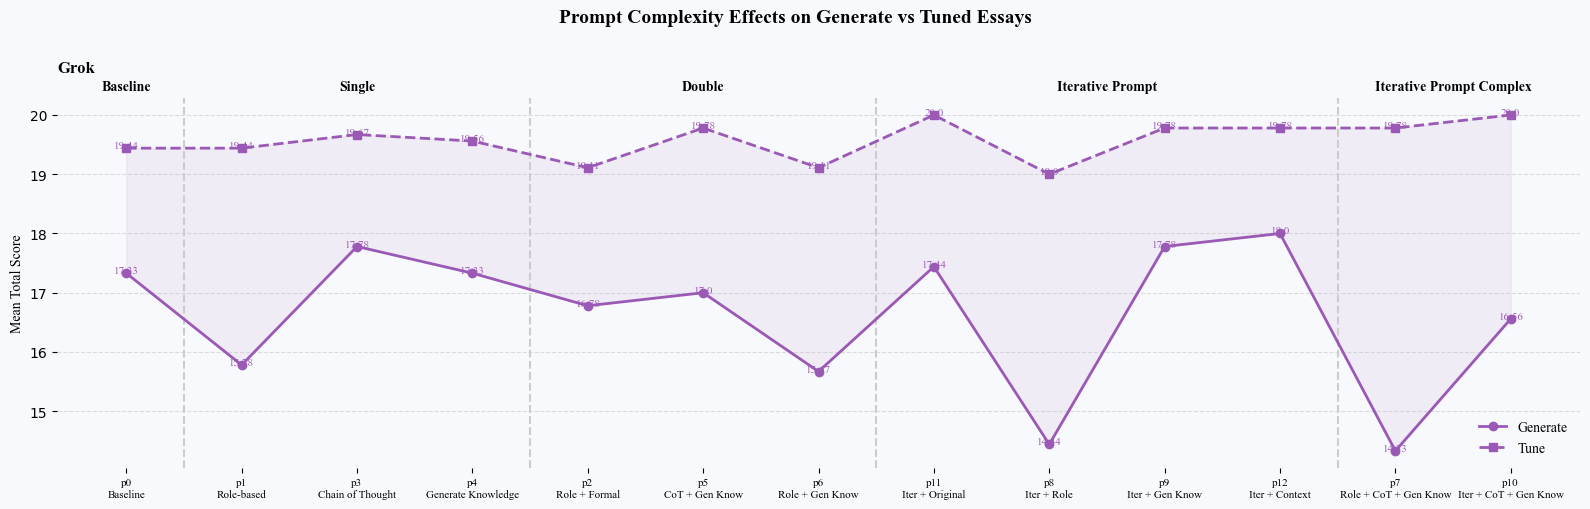

In [26]:
visualize.plot_trend(trend_df, prompt_order, ['grok'], technique_groups, PROMPT_LABELS)

Overall trends: (Grok)

- Tune scores consistently outperform Generate scores across all prompt techniques.
- Tune scores are relatively stable (≈18.4–19.8), with moderate fluctuation.
- Generate scores are highly volatile and significantly lower overall.
- The performance gap between Generate and Tune is the largest among all models.
- Prompt complexity often highlight instability for Generate.

- Baseline:
  - The gap (~2.0 points) is already large at basic prompt.
  
- Single Prompt Additions:
  - Role prompting significantly destabilizes Generate performance.
  
- Double Prompt Additions:
  - Role combinations consistently produce the weakest Generate scores.

- Iterative Prompt:
  - Iteration helps only when not paired with role prompting.

- Iterative Complex:
  - Highest structural complexity does not improve performance and may worsen it.